<a href="https://colab.research.google.com/github/Balamurugan-T326/Machine-Learning/blob/main/Experiment-9/sc-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Roll No: 24BAD016
# Name: Balamurugan T

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

In [2]:
ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703.0
1,1,3,4.0,964981247.0
2,1,6,4.0,964982224.0
3,1,47,5.0,964983815.0
4,1,50,5.0,964982931.0


In [3]:
print(ratings.info())
print(ratings.describe())

print("Unique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43084 entries, 0 to 43083
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     43084 non-null  int64  
 1   movieId    43084 non-null  int64  
 2   rating     43084 non-null  float64
 3   timestamp  43083 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 1.3 MB
None
             userId        movieId        rating     timestamp
count  43084.000000   43084.000000  43084.000000  4.308300e+04
mean     145.216206   18582.328103      3.566951  1.181536e+09
std       85.595025   35281.316493      1.022535  2.146729e+08
min        1.000000       1.000000      0.500000  8.293223e+08
25%       68.000000    1090.000000      3.000000  9.785596e+08
50%      140.000000    2791.000000      4.000000  1.161566e+09
75%      221.000000    7155.000000      4.000000  1.393542e+09
max      288.000000  193587.000000      5.000000  1.537650e+09
Unique Users: 288
Unique Movie

In [4]:
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193571,193573,193579,193581,193583,193585,193587
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [6]:
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,279,280,281,282,283,284,285,286,287,288
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.186476,0.080486,0.046002,0.246836,0.127859,0.129047,0.024877,0.168053,0.175110,0.346579
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.236086,0.046662,0.000000,0.142717,0.083982,0.035992,0.034051,0.039066,0.012408,0.025041
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.020219,0.005414,0.000000,0.005572,0.000000,0.000000,0.002572,0.002499,0.006073,0.043031
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.093187,0.094150,0.049376,0.166132,0.088068,0.071569,0.099432,0.110276,0.148797,0.221887
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.085932,0.082815,0.000000,0.105786,0.149698,0.320258,0.055834,0.112712,0.084555,0.156437


In [7]:
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    return similar_users.iloc[1:n+1]

get_similar_users(1)

,1
userId,
266,0.357408
288,0.346579
57,0.345034
91,0.334727
39,0.329782


In [8]:
def predict_rating(user_id, movie_id):
    similar_users = get_similar_users(user_id, 5)

    numerator = 0
    denominator = 0

    for sim_user, similarity in similar_users.items():
        rating = user_item_matrix.loc[sim_user, movie_id]

        if not np.isnan(rating):
            numerator += similarity * rating
            denominator += similarity

    if denominator == 0:
        return 0
    return numerator / denominator

predict_rating(1, 10)

np.float64(3.1630682630417546)

In [9]:
def recommend_movies(user_id, n=5):
    user_rated = user_item_matrix.loc[user_id]
    unrated_movies = user_rated[user_rated.isna()].index

    predictions = []

    for movie in unrated_movies:
        pred = predict_rating(user_id, movie)
        predictions.append((movie, pred))

    predictions.sort(key=lambda x: x[1], reverse=True)

    top_movies = predictions[:n]

    movie_ids = [movie[0] for movie in top_movies]

    return movies[movies['movieId'].isin(movie_ids)]

recommend_movies(1)

,movieId,title,genres
311,353,"Crow, The (1994)",Action|Crime|Fantasy|Thriller
449,514,"Ref, The (1994)",Comedy
585,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy
695,913,"Maltese Falcon, The (1941)",Film-Noir|Mystery
906,1204,Lawrence of Arabia (1962),Adventure|Drama|War


In [10]:
y_true = []
y_pred = []

for row in ratings.itertuples():
    pred = predict_rating(row.userId, row.movieId)

    if pred > 0:
        y_true.append(row.rating)
        y_pred.append(pred)

rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.051508823640234
MAE: 0.8007956319416581


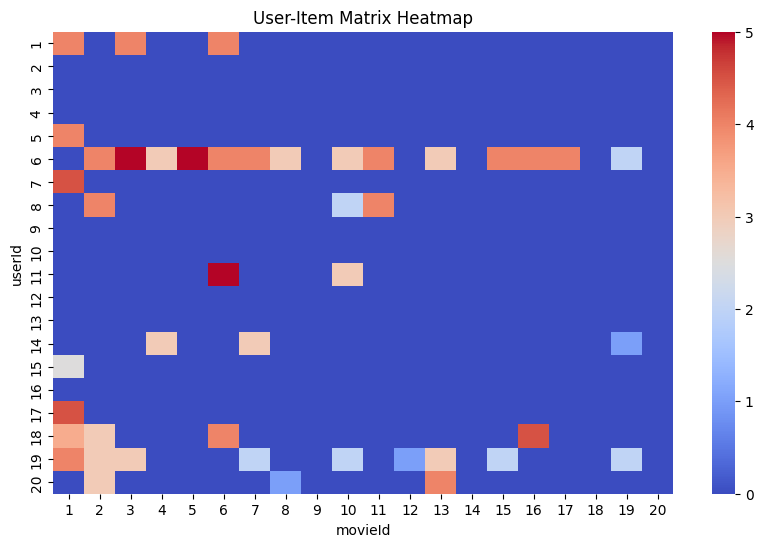

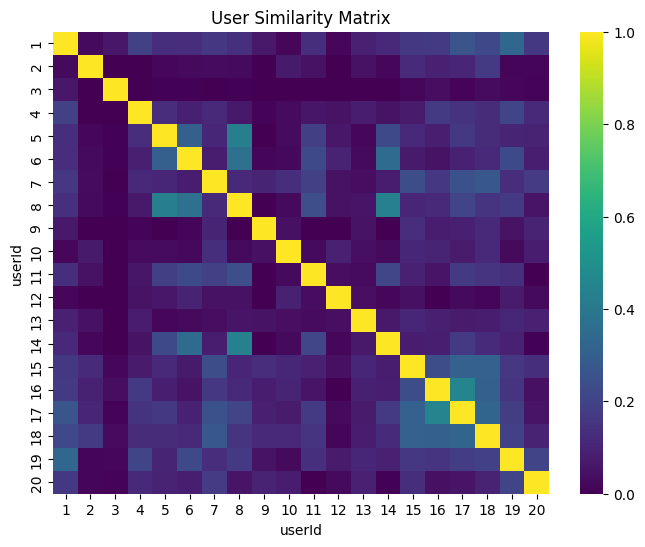

In [11]:

plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap='coolwarm')
plt.title("User-Item Matrix Heatmap")
plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("User Similarity Matrix")
plt.show()